In [39]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
%pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [42]:
from sklearn.linear_model import Ridge

In [43]:
file_path = "data/cleaned_debris2.csv"
df = pd.read_csv(file_path)

In [44]:
print("Shape:", df.shape)
print(df.head())
print(df.tail())

Shape: (816, 8)
      Date  Spacecraft  Rocket Bodies  Mission-Related Debris  \
0  1957.00         0.0            0.0                     0.0   
1  1957.09         0.0            0.0                     0.0   
2  1957.16         0.0            0.0                     0.0   
3  1957.25         0.0            0.0                     0.0   
4  1957.33         0.0            0.0                     0.0   

   Fragmentation Debris  Unassigned Type  Total  Year  
0                   0.0              0.0    0.0  1957  
1                   0.0              0.0    0.0  1957  
2                   0.0              0.0    0.0  1957  
3                   0.0              0.0    0.0  1957  
4                   0.0              0.0    0.0  1957  
        Date  Spacecraft  Rocket Bodies  Mission-Related Debris  \
811  2024.58     13032.0         2128.0                  1888.0   
812  2024.67     13046.0         2124.0                  1895.0   
813  2024.75     13151.0         2129.0                 

In [45]:
print(df.isnull().sum())

Date                      0
Spacecraft                0
Rocket Bodies             0
Mission-Related Debris    0
Fragmentation Debris      0
Unassigned Type           0
Total                     0
Year                      0
dtype: int64


In [46]:
print("Total null values:", df.isnull().sum().sum())

Total null values: 0


In [47]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [48]:
print(df.dtypes)

Date                      float64
Spacecraft                float64
Rocket Bodies             float64
Mission-Related Debris    float64
Fragmentation Debris      float64
Unassigned Type           float64
Total                     float64
Year                        int64
dtype: object


In [49]:
df.head()

,Date,Spacecraft,Rocket Bodies,Mission-Related Debris,Fragmentation Debris,Unassigned Type,Total,Year
0,1957.00,0.0,0.0,0.0,0.0,0.0,0.0,1957
1,1957.09,0.0,0.0,0.0,0.0,0.0,0.0,1957
2,1957.16,0.0,0.0,0.0,0.0,0.0,0.0,1957
3,1957.25,0.0,0.0,0.0,0.0,0.0,0.0,1957
4,1957.33,0.0,0.0,0.0,0.0,0.0,0.0,1957


In [50]:
df.tail()

,Date,Spacecraft,Rocket Bodies,Mission-Related Debris,Fragmentation Debris,Unassigned Type,Total,Year
811,2024.58,13032.0,2128.0,1888.0,12064.0,563.0,29675.0,2024
812,2024.67,13046.0,2124.0,1895.0,12015.0,572.0,29652.0,2024
813,2024.75,13151.0,2129.0,1890.0,11972.0,563.0,29705.0,2024
814,2024.84,13357.0,2137.0,1889.0,11900.0,629.0,29912.0,2024
815,2024.92,13449.0,2136.0,1877.0,11791.0,621.0,29874.0,2024


In [51]:
df["Debris"] = (
    df["Rocket Bodies"]
    + df["Mission-Related Debris"]
    + df["Fragmentation Debris"]
    + df["Unassigned Type"]
)

In [52]:
print(df.shape)
print(df[["Date", "Total", "Debris"]].tail(10))

(816, 9)
        Date    Total   Debris
806  2024.17  28528.0  16245.0
807  2024.25  28637.0  16192.0
808  2024.33  28762.0  16122.0
809  2024.42  28831.0  16079.0
810  2024.50  28793.0  16009.0
811  2024.58  29675.0  16643.0
812  2024.67  29652.0  16606.0
813  2024.75  29705.0  16554.0
814  2024.84  29912.0  16555.0
815  2024.92  29874.0  16425.0


In [53]:
df = df.sort_values("Date").reset_index(drop=True)

In [54]:
df["Debris_lag_1"] = df["Debris"].shift(1)
df["Debris_lag_2"] = df["Debris"].shift(2)
df["Debris_lag_3"] = df["Debris"].shift(3)
df["Debris_lag_6"] = df["Debris"].shift(6)
df["Debris_lag_12"] = df["Debris"].shift(12)

In [55]:
df["Growth"] = df["Debris"].diff()

df["Growth_lag_1"] = df["Growth"].shift(1)
df["Growth_lag_3"] = df["Growth"].shift(3)
df["Growth_lag_12"] = df["Growth"].shift(12)

In [56]:
df["Time"] = np.arange(len(df))

In [57]:
df = df.dropna().reset_index(drop=True)

In [58]:
print(df.shape)

(803, 19)


In [59]:
df[
    [
        "Date",
        "Debris",
        "Debris_lag_1",
        "Debris_lag_3",
        "Debris_lag_12",
        "Growth",
        "Growth_lag_1",
        "Time"
    ]
].head(10)

,Date,Debris,Debris_lag_1,Debris_lag_3,Debris_lag_12,Growth,Growth_lag_1,Time
0,1958.09,0.0,0.0,1.0,0.0,0.0,-1.0,13
1,1958.16,2.0,0.0,1.0,0.0,2.0,0.0,14
2,1958.25,2.0,2.0,0.0,0.0,0.0,2.0,15
3,1958.33,3.0,2.0,0.0,0.0,1.0,0.0,16
4,1958.42,3.0,3.0,2.0,0.0,0.0,1.0,17
5,1958.50,3.0,3.0,2.0,0.0,0.0,0.0,18
6,1958.58,3.0,3.0,3.0,0.0,0.0,0.0,19
7,1958.67,3.0,3.0,3.0,0.0,0.0,0.0,20
8,1958.75,3.0,3.0,3.0,1.0,0.0,0.0,21
9,1958.84,3.0,3.0,3.0,1.0,0.0,0.0,22


In [60]:
target = "Debris"

predictors = [
    "Debris_lag_1",
    "Debris_lag_2",
    "Debris_lag_3",
    "Debris_lag_6",
    "Debris_lag_12",
    "Growth_lag_1",
    "Growth_lag_3",
    "Growth_lag_12",
    "Time"
]

In [61]:
split = int(len(df) * 0.8)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

X_train = train[predictors]
y_train = train[target]

X_test = test[predictors]
y_test = test[target]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Training period:", train["Date"].min(), "to", train["Date"].max())
print("Testing period:", test["Date"].min(), "to", test["Date"].max())

Train: (642, 9)
Test: (161, 9)
Training period: 1958.09 to 2011.5
Testing period: 2011.58 to 2024.92


In [62]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, ridge_pred)
rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
mape = np.mean(np.abs((y_test - ridge_pred) / y_test)) * 100
r2 = r2_score(y_test, ridge_pred)

print("Ridge Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")
print("R²  :", r2)

Ridge Results
MAE : 78.70682211176832
RMSE: 179.32638850496826
MAPE: 0.4889012475509146 %
R²  : 0.9639355247546031


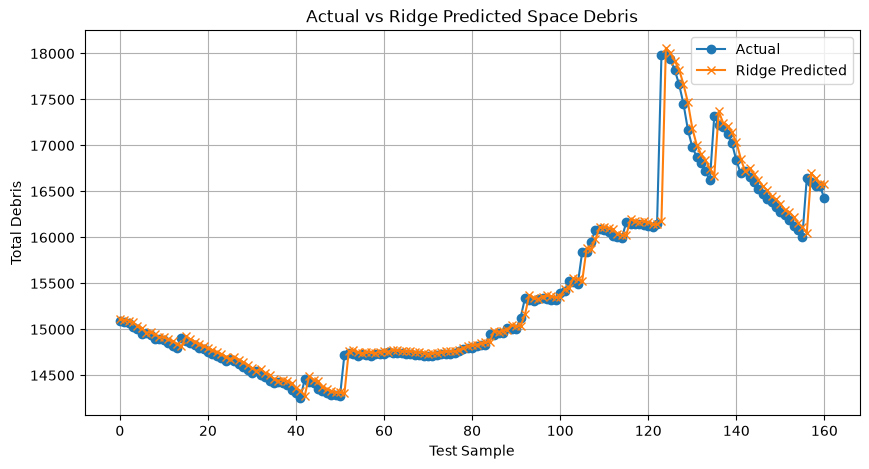

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual",
    marker="o"
)

plt.plot(
    ridge_pred,
    label="Ridge Predicted",
    marker="x"
)

plt.title("Actual vs Ridge Predicted Space Debris")
plt.xlabel("Test Sample")
plt.ylabel("Total Debris")
plt.legend()
plt.grid(True)

plt.show()

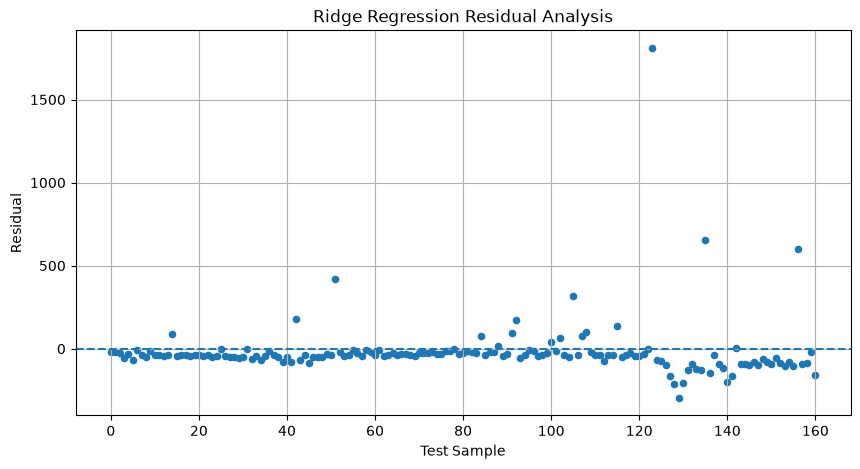

In [65]:
residuals = y_test.values - ridge_pred

plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuals)), residuals, s=20)
plt.axhline(0, linestyle="--")

plt.xlabel("Test Sample")
plt.ylabel("Residual")
plt.title("Ridge Regression Residual Analysis")
plt.grid(True)
plt.show()

In [66]:
# ============================================
# RIDGE FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    "Feature": predictors,
    "Coefficient": ridge.coef_
})

importance["Absolute Impact"] = np.abs(importance["Coefficient"])

importance = importance.sort_values(
    "Absolute Impact",
    ascending=False
)

print("Ridge Feature Importance:")
display(importance)

Ridge Feature Importance:


,Feature,Coefficient,Absolute Impact
0,Debris_lag_1,0.672795,0.672795
5,Growth_lag_1,0.351298,0.351298
1,Debris_lag_2,0.321495,0.321495
8,Time,0.234071,0.234071
7,Growth_lag_12,0.013096,0.013096
2,Debris_lag_3,-0.009111,0.009111
6,Growth_lag_3,-0.008154,0.008154
3,Debris_lag_6,0.006718,0.006718
4,Debris_lag_12,-0.001292,0.001292


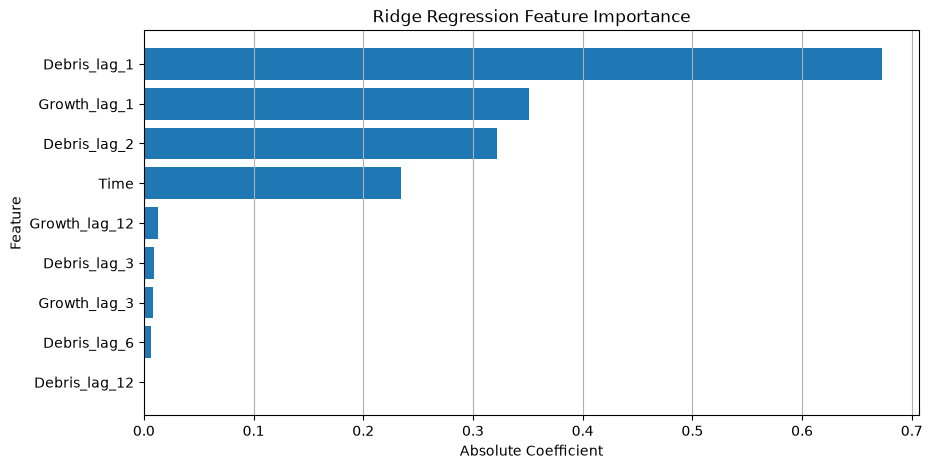

In [67]:
plt.figure(figsize=(10, 5))

plt.barh(
    importance["Feature"],
    importance["Absolute Impact"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Ridge Regression Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [68]:
import joblib
import os

# Save model
joblib.dump(ridge, "ridge_model.pkl")

# Save feature list
joblib.dump(predictors, "ridge_features.pkl")

print("Ridge model saved successfully.")
print("Features saved successfully.")

Ridge model saved successfully.
Features saved successfully.


In [69]:
import os

print("ridge_model.pkl:", os.path.exists("ridge_model.pkl"))
print("ridge_features.pkl:", os.path.exists("ridge_features.pkl"))

ridge_model.pkl: True
ridge_features.pkl: True


In [70]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(ridge, "models/ridge_debris_model.pkl")

print("Ridge model saved successfully")

Ridge model saved successfully


In [72]:
print(ridge.feature_names_in_)

['Debris_lag_1' 'Debris_lag_2' 'Debris_lag_3' 'Debris_lag_6'
 'Debris_lag_12' 'Growth_lag_1' 'Growth_lag_3' 'Growth_lag_12' 'Time']


In [73]:
print(df[["Date", "Time"]].head(10))
print("\nLast rows:")
print(df[["Date", "Time"]].tail(10))

      Date  Time
0  1958.09    13
1  1958.16    14
2  1958.25    15
3  1958.33    16
4  1958.42    17
5  1958.50    18
6  1958.58    19
7  1958.67    20
8  1958.75    21
9  1958.84    22

Last rows:
        Date  Time
793  2024.17   806
794  2024.25   807
795  2024.33   808
796  2024.42   809
797  2024.50   810
798  2024.58   811
799  2024.67   812
800  2024.75   813
801  2024.84   814
802  2024.92   815


In [74]:
print("\nTime statistics:")
print(df["Time"].describe())


Time statistics:
count    803.000000
mean     414.000000
std      231.950426
min       13.000000
25%      213.500000
50%      414.000000
75%      614.500000
max      815.000000
Name: Time, dtype: float64


In [76]:
ridge_features = [
    "Debris_lag_1",
    "Debris_lag_2",
    "Debris_lag_3",
    "Debris_lag_6",
    "Debris_lag_12",
    "Growth_lag_1",
    "Growth_lag_3",
    "Growth_lag_12",
    "Time"
]

In [80]:
# ============================================================
# INTERACTIVE FUTURE DEBRIS PREDICTION
# Uses the already-trained Ridge model: ridge
# Uses the existing dataframe: df
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Exact feature order used when training Ridge
# ------------------------------------------------------------

predictors = [
    "Debris_lag_1",
    "Debris_lag_2",
    "Debris_lag_3",
    "Debris_lag_6",
    "Debris_lag_12",
    "Growth_lag_1",
    "Growth_lag_3",
    "Growth_lag_12",
    "Time"
]

# ------------------------------------------------------------
# Get target year from user
# ------------------------------------------------------------

target_year = int(
    input("Enter the year to predict (e.g. 2045): ")
)

# ------------------------------------------------------------
# Check target year
# ------------------------------------------------------------

last_year = float(df["Date"].iloc[-1])

if target_year <= last_year:

    print(
        f"\nPlease enter a year after {last_year:.2f}"
    )

else:

    # --------------------------------------------------------
    # Start with REAL historical data
    # --------------------------------------------------------

    history_debris = list(
        df["Debris"].astype(float)
    )

    # Calculate historical growth
    history_growth = list(
        df["Debris"]
        .astype(float)
        .diff()
        .fillna(0)
    )

    # Last known values
    current_date = last_year
    current_time = int(df["Time"].iloc[-1])

    # Number of monthly predictions
    steps = int(
        round((target_year - current_date) * 12)
    )

    # --------------------------------------------------------
    # Recursive forecasting
    # --------------------------------------------------------

    predicted = history_debris[-1]

    for step in range(steps):

        current_date += 1 / 12
        current_time += 1

        # ----------------------------------------------
        # Create the exact features used during training
        # ----------------------------------------------

        feature_values = {
            "Debris_lag_1": history_debris[-1],
            "Debris_lag_2": history_debris[-2],
            "Debris_lag_3": history_debris[-3],
            "Debris_lag_6": history_debris[-6],
            "Debris_lag_12": history_debris[-12],

            "Growth_lag_1": history_growth[-1],
            "Growth_lag_3": history_growth[-3],
            "Growth_lag_12": history_growth[-12],

            "Time": current_time
        }

        # ----------------------------------------------
        # DataFrame in EXACT training order
        # ----------------------------------------------

        X_future = pd.DataFrame(
            [[feature_values[col] for col in predictors]],
            columns=predictors
        )

        # ----------------------------------------------
        # Use YOUR already-trained Ridge model
        # ----------------------------------------------

        predicted = float(
            ridge.predict(X_future)[0]
        )

        # Debris cannot be negative
        predicted = max(0, predicted)

        # ----------------------------------------------
        # Calculate growth
        # This becomes input for the next prediction
        # ----------------------------------------------

        growth = (
            predicted -
            history_debris[-1]
        )

        # ----------------------------------------------
        # Add prediction to history
        # ----------------------------------------------

        history_debris.append(predicted)
        history_growth.append(growth)

    # --------------------------------------------------------
    # Display result
    # --------------------------------------------------------

    print("\n" + "=" * 45)
    print("       FUTURE DEBRIS PREDICTION")
    print("=" * 45)

    print(
        f"Target Year       : {target_year}"
    )

    print(
        f"Predicted Debris  : {predicted:,.2f}"
    )

    print("=" * 45)


       FUTURE DEBRIS PREDICTION
Target Year       : 2040
Predicted Debris  : 21,945.94


In [79]:
print("Latest historical debris:", df["Debris"].iloc[-1])
print("2030 predicted total:", predicted)

Latest historical debris: 16425.0
2030 predicted total: 18489.004075092715


In [81]:
print("Shape:", df.shape)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nMissing values:")
print(df[["Date", "Debris", "Time"]].isnull().sum())

print("\nDuplicate dates:")
print(df["Date"].duplicated().sum())

print("\nNegative debris values:")
print((df["Debris"] < 0).sum())

print("\nFirst 10:")
print(df[["Date", "Debris", "Time"]].head(10))

print("\nLast 10:")
print(df[["Date", "Debris", "Time"]].tail(10))

Shape: (803, 19)

Date range:
1958.09 to 2024.92

Missing values:
Date      0
Debris    0
Time      0
dtype: int64

Duplicate dates:
0

Negative debris values:
0

First 10:
      Date  Debris  Time
0  1958.09     0.0    13
1  1958.16     2.0    14
2  1958.25     2.0    15
3  1958.33     3.0    16
4  1958.42     3.0    17
5  1958.50     3.0    18
6  1958.58     3.0    19
7  1958.67     3.0    20
8  1958.75     3.0    21
9  1958.84     3.0    22

Last 10:
        Date   Debris  Time
793  2024.17  16245.0   806
794  2024.25  16192.0   807
795  2024.33  16122.0   808
796  2024.42  16079.0   809
797  2024.50  16009.0   810
798  2024.58  16643.0   811
799  2024.67  16606.0   812
800  2024.75  16554.0   813
801  2024.84  16555.0   814
802  2024.92  16425.0   815


In [82]:
dates = df["Date"].sort_values().reset_index(drop=True)

differences = dates.diff().dropna()

print(differences.describe())
print("\nMost common time difference:")
print(differences.value_counts().head(10))

count    802.000000
mean       0.083329
std        0.005892
min        0.070000
25%        0.080000
50%        0.080000
75%        0.090000
max        0.090000
Name: Date, dtype: float64

Most common time difference:
Date
0.08    351
0.09    183
0.09    134
0.08     84
0.07     50
Name: count, dtype: int64


In [83]:
print("===== DATASET RANGE =====")
print("First date :", df["Date"].iloc[0])
print("Last date  :", df["Date"].iloc[-1])

print("\n===== DEBRIS VALUES =====")
print("First debris:", df["Debris"].iloc[0])
print("Last debris :", df["Debris"].iloc[-1])

print("\n===== LAST 20 OBSERVATIONS =====")
print(df[["Date", "Debris"]].tail(20).to_string(index=False))

===== DATASET RANGE =====
First date : 1958.09
Last date  : 2024.92

===== DEBRIS VALUES =====
First debris: 0.0
Last debris : 16425.0

===== LAST 20 OBSERVATIONS =====
   Date  Debris
2023.33 16695.0
2023.42 16722.0
2023.50 16661.0
2023.58 16597.0
2023.67 16528.0
2023.75 16474.0
2023.84 16415.0
2023.92 16382.0
2024.00 16334.0
2024.09 16271.0
2024.17 16245.0
2024.25 16192.0
2024.33 16122.0
2024.42 16079.0
2024.50 16009.0
2024.58 16643.0
2024.67 16606.0
2024.75 16554.0
2024.84 16555.0
2024.92 16425.0


In [84]:
df["Debris_change"] = df["Debris"].diff()

print("===== LARGEST DEBRIS CHANGES =====")
print(
    df[["Date", "Debris", "Debris_change"]]
    .sort_values("Debris_change", key=lambda x: x.abs(), ascending=False)
    .head(15)
    .to_string(index=False)
)

===== LARGEST DEBRIS CHANGES =====
   Date  Debris  Debris_change
2007.00 12367.0         3478.0
2009.09 15172.0         2358.0
2021.84 17986.0         1841.0
1996.42  8593.0          753.0
2022.84 17325.0          704.0
2024.58 16643.0          634.0
1970.75  2781.0          587.0
2008.17 13293.0          497.0
1965.75  1462.0          477.0
1981.50  5602.0          469.0
1986.84  7159.0          466.0
2015.84 14725.0          452.0
2001.92  8721.0          377.0
2020.33 15841.0          344.0
2000.17  8605.0          342.0


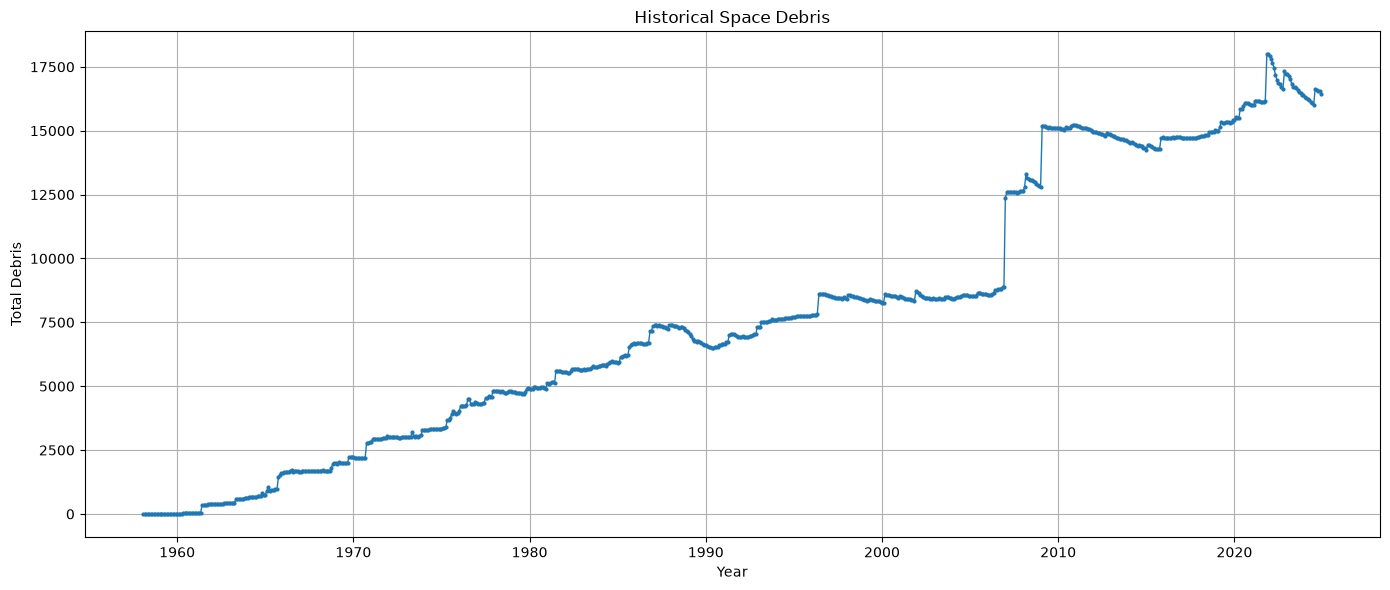

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Debris"],
    marker="o",
    markersize=2,
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Total Debris")
plt.title("Historical Space Debris")

plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
import pandas as pd
import numpy as np
import joblib

# Load the model and EXACT feature order used during training
ridge_model = joblib.load("ridge_model.pkl")
ridge_features = joblib.load("ridge_features.pkl")

print("Model loaded successfully")
print("Features:", ridge_features)

Model loaded successfully
Features: ['Debris_lag_1', 'Debris_lag_2', 'Debris_lag_3', 'Debris_lag_6', 'Debris_lag_12', 'Growth_lag_1', 'Growth_lag_3', 'Growth_lag_12', 'Time']


In [87]:
# Make sure data is sorted
df = df.sort_values("Date").reset_index(drop=True)

# Historical debris and growth
debris_history = df["Debris"].astype(float).tolist()
growth_history = df["Growth"].astype(float).tolist()
time_history = df["Time"].astype(float).tolist()

# Last known values
last_time = time_history[-1]

# Number of future observations
# Dataset has approximately 12 observations per year
future_years = 21
future_steps = future_years * 12

future_predictions = []
future_dates = []

for step in range(1, future_steps + 1):

    # Lag features
    features = {
        "Debris_lag_1": debris_history[-1],
        "Debris_lag_2": debris_history[-2],
        "Debris_lag_3": debris_history[-3],
        "Debris_lag_6": debris_history[-6],
        "Debris_lag_12": debris_history[-12],

        "Growth_lag_1": growth_history[-1],
        "Growth_lag_3": growth_history[-3],
        "Growth_lag_12": growth_history[-12],

        "Time": last_time + step
    }

    # EXACT training feature order
    X_future = pd.DataFrame(
        [[features[col] for col in ridge_features]],
        columns=ridge_features
    )

    # Predict
    predicted = float(ridge_model.predict(X_future)[0])
    predicted = max(0, predicted)

    # Calculate predicted growth
    predicted_growth = predicted - debris_history[-1]

    # Store
    debris_history.append(predicted)
    growth_history.append(predicted_growth)

    # Convert observation number back to year
    predicted_date = df["Date"].iloc[-1] + (step / 12)

    future_dates.append(predicted_date)
    future_predictions.append(predicted)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Debris": future_predictions
})

future_df.head()

,Date,Predicted_Debris
0,2025.003333,16452.615416
1,2025.086667,16488.707608
2,2025.170000,16527.602663
3,2025.253333,16564.421914
4,2025.336667,16600.679704


In [88]:
future_df["Year"] = future_df["Date"].astype(int)

print(
    future_df[
        future_df["Year"].isin([2025, 2030, 2035, 2040, 2045])
    ][["Date", "Predicted_Debris"]]
)

            Date  Predicted_Debris
0    2025.003333      16452.615416
1    2025.086667      16488.707608
2    2025.170000      16527.602663
3    2025.253333      16564.421914
4    2025.336667      16600.679704
5    2025.420000      16636.106358
6    2025.503333      16671.143871
7    2025.586667      16714.520409
8    2025.670000      16749.337828
9    2025.753333      16783.737459
10   2025.836667      16818.635410
11   2025.920000      16852.026046
60   2030.003333      18489.004075
61   2030.086667      18520.505965
62   2030.170000      18551.943658
63   2030.253333      18583.317782
64   2030.336667      18614.628954
65   2030.420000      18645.877788
66   2030.503333      18677.064891
67   2030.586667      18708.190865
68   2030.670000      18739.256306
69   2030.753333      18770.261801
70   2030.836667      18801.207937
71   2030.920000      18832.095290
120  2035.003333      20284.216602
121  2035.086667      20312.791175
122  2035.170000      20341.330068
123  2035.253333    

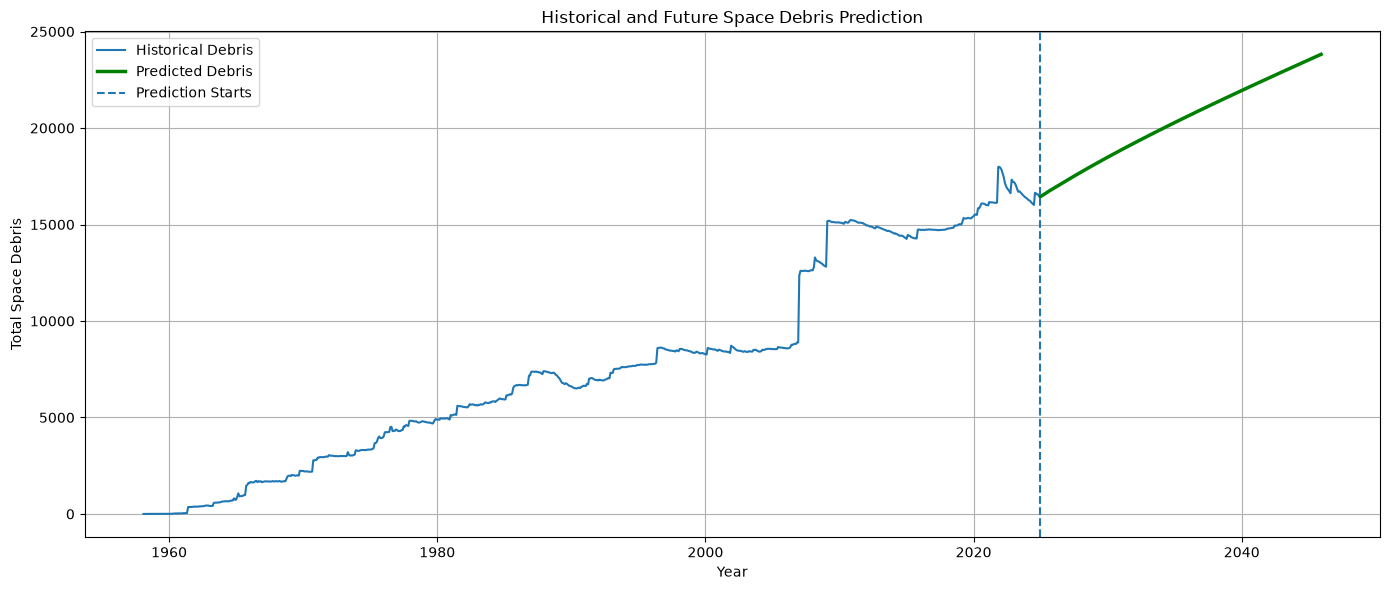

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Historical
plt.plot(
    df["Date"],
    df["Debris"],
    label="Historical Debris"
)

# Future prediction
plt.plot(
    future_df["Date"],
    future_df["Predicted_Debris"],
    color="green",
    linewidth=2.5,
    label="Predicted Debris"
)

# Mark prediction starting point
plt.axvline(
    x=df["Date"].iloc[-1],
    linestyle="--",
    label="Prediction Starts"
)

plt.xlabel("Year")
plt.ylabel("Total Space Debris")
plt.title("Historical and Future Space Debris Prediction")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [90]:
import json
import os

# Save the model-generated future predictions
output = future_df[["Date", "Predicted_Debris"]].copy()

output["Year"] = output["Date"].astype(int)

# Keep one prediction for each year
yearly_predictions = (
    output
    .groupby("Year", as_index=False)
    .last()
)

# Save inside backend
output_path = "../future_predictions.json"

yearly_predictions.to_json(
    output_path,
    orient="records",
    indent=2
)

print("Future predictions saved to:")
print(os.path.abspath(output_path))

print("\nSample:")
print(yearly_predictions.head())

Future predictions saved to:
d:\projects\debris\backend\future_predictions.json

Sample:
   Year     Date  Predicted_Debris
0  2025  2025.92      16852.026046
1  2026  2026.92      17271.986342
2  2027  2027.92      17678.632014
3  2028  2028.92      18073.341711
4  2029  2029.92      18457.437358
